# Demo: rainbow_corr_dataset

Minimal end-to-end run of `build_dataset` from `rainbow_corr_dataset.py`.
Uses synthetic GBM prices so the notebook is self-contained and reproducible.
To run on real data: replace `make_synthetic_prices` with `FinanceLib.download_data` (yfinance).

In [57]:
import os
import shutil
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

sys.path.insert(0, os.getcwd())

from rainbow_corr_dataset import build_dataset, run_sanity_checks

## 1. Synthetic asset universe (5 assets, ~7 years)

Correlated GBM with random drifts and volatilities. Replace this cell with `download_data(...)` to use real tickers.

In [2]:
def make_synthetic_prices(n_assets=5, n_days=7 * 252, seed=7):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range('2017-01-02', periods=n_days)
    mu = rng.uniform(0.05, 0.12, size=n_assets)
    sig = rng.uniform(0.15, 0.40, size=n_assets)
    A = rng.normal(size=(n_assets, n_assets))
    C = (A @ A.T) / n_assets
    d = np.sqrt(np.diag(C))
    R = C / np.outer(d, d)
    L = np.linalg.cholesky(R + 1e-6 * np.eye(n_assets))
    dt = 1.0 / 252
    Z = rng.standard_normal((n_days - 1, n_assets)) @ L.T
    log_increments = (mu[None, :] - 0.5 * sig[None, :] ** 2) * dt + sig[None, :] * np.sqrt(dt) * Z
    S0 = rng.uniform(50.0, 200.0, size=n_assets)
    log_S = np.vstack([np.log(S0)[None, :], np.cumsum(log_increments, axis=0) + np.log(S0)[None, :]])
    S = np.exp(log_S)
    out = {}
    for i in range(n_assets):
        name = f'ASSET_{i:02d}'
        df = pd.DataFrame({'Close': S[:, i]}, index=dates)
        df.index.name = 'Date'
        out[name] = df
    return out

price_data = make_synthetic_prices()
tickers = list(price_data.keys())
tickers

['ASSET_00', 'ASSET_01', 'ASSET_02', 'ASSET_03', 'ASSET_04']

## 1.1 Загузука реальных данных

In [ ]:
# Загрузка реальных данных с yfinance
import importlib
import FinanceLib
importlib.reload(FinanceLib)

tickers_real = {
    "Apple"         : "AAPL",
    "Microsoft"         : "MSFT",
    "Alphabet"          : "GOOGL",
    "Amazon"            : "AMZN",
    "Meta"          : "META",
    "Nvidia"            : "NVDA",
    "Tesla"         : "TSLA",
    "Cisco"         : "CSCO",
    "Intel"         : "INTC",
    "Oracle"            : "ORCL",
    "Chevron"           : "CVX",
    "Visa"          : "V",
    "Walmart"           : "WMT",
    "Exxon Mobil"           : "XOM",
    "Coca-Cola"         : "KO",
    "PepsiCo"           : "PEP",
    # "Broadcom": "AVGO",
    # "JPMorgan": "JPM",
    # "Johnson & Johnson": "JNJ",
    # "UnitedHealth": "UNH",
    # "Mastercard": "MA",
    # "Disney": "DIS",
    # "Bank of America": "BAC",
    # "Pfizer": "PFE",
    # "AbbVie": "ABBV",
    # "Merck": "MRK",
    # "Adobe": "ADBE",
}

companies = FinanceLib.download_data(tickers_real, start="1998-01-01", end="2025-01-01")

# Подменяем синтетические price_data / tickers реальными данными из companies,
# чтобы все последующие ячейки (график, build_dataset, ...) работали с yfinance-данными.
price_data = {name: df for name, df in companies.items() if df is not None and not df.empty}
tickers = list(price_data.keys())

print(f"Загружено тикеров: {len(price_data)}")
print(f"Список: {tickers}")
_ref = price_data[tickers[0]]
print(
    f"Пример ({tickers[0]}): "
    f"{_ref.index.min().date()} -> {_ref.index.max().date()}, "
    f"{len(_ref)} строк, колонки: {list(_ref.columns)}"
)
companies


Загружено тикеров: 16
Список: ['Apple', 'Microsoft', 'Alphabet', 'Amazon', 'Meta', 'Nvidia', 'Tesla', 'Visa', 'Walmart', 'Exxon Mobil', 'Coca-Cola', 'PepsiCo', 'Cisco', 'Intel', 'Oracle', 'Chevron']
Пример (Apple): 1998-01-02 -> 2024-12-31, 6793 строк, колонки: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


{'Apple': Price        Adj Close       Close        High         Low        Open  \
 Date                                                                     
 1998-01-02    0.121612    0.145089    0.145089    0.120536    0.121652   
 1998-01-05    0.118806    0.141741    0.147879    0.135603    0.147321   
 1998-01-06    0.141726    0.169085    0.178571    0.131696    0.142299   
 1998-01-07    0.130968    0.156250    0.169643    0.154576    0.167969   
 1998-01-08    0.136112    0.162388    0.166295    0.151228    0.155692   
 ...                ...         ...         ...         ...         ...   
 2024-12-24  256.560822  258.200012  258.209991  255.289993  255.490005   
 2024-12-26  257.375580  259.019989  260.100006  257.630005  258.190002   
 2024-12-27  253.967392  255.589996  258.700012  253.059998  257.829987   
 2024-12-30  250.598892  252.199997  253.500000  250.750000  252.229996   
 2024-12-31  248.830200  250.419998  253.279999  249.429993  252.440002   
 
 Price        

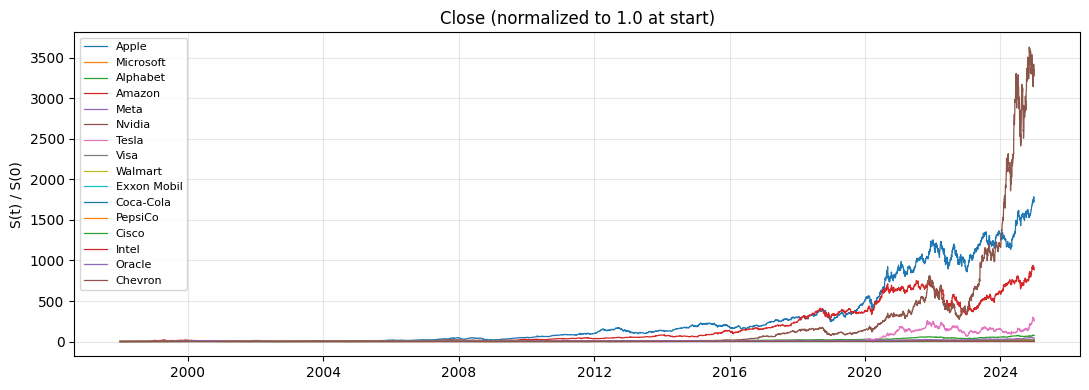

In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
for t in tickers:
    ax.plot(price_data[t].index, price_data[t]['Close'] / price_data[t]['Close'].iloc[0], label=t, lw=0.9)
ax.set_title('Close (normalized to 1.0 at start)')
ax.set_ylabel('S(t) / S(0)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 2. Standalone sanity (no data needed)

In [21]:
_ = run_sanity_checks(verbose=True)

  BS put vs MC: bs=4.0825 mc=4.0458 se=0.0222 ok=True
  Stulz vs MC: stulz=8.8497 mc=8.8379 se=0.0437 ok=True
  Stulz monotone in rho: p(-0.5)=9.8490 > p(0.99)=7.4291? ok=True


## 3. Build dataset

Monthly inception (last business day of each month), 4 maturities x 6 strikes by default.
For demo we shrink to 2 maturities and 3 strikes.

In [22]:
out_dir = os.path.join('ml output', 'rainbow_demo')
if os.path.isdir(out_dir):
    shutil.rmtree(out_dir)

summary = build_dataset(
    price_data,
    derivative_filter=tickers,
    output_dir=out_dir,
    maturities_bd=(21, 63),
    strike_pcts=(0.9, 1.0, 1.1),
    inception_freq='BME',
    write_fv_trajectory=True,
    compute_greeks=False,
    verbose=True,
    fv_progress_every=0,
)
summary

[1/4] precompute_market_state on 16 assets
  AR(1) calibration: pair 1/120 (Alphabet, Amazon)
  AR(1) calibration: pair 13/120 (Alphabet, Tesla)
  AR(1) calibration: pair 25/120 (Amazon, Oracle)
  AR(1) calibration: pair 37/120 (Apple, Nvidia)
  AR(1) calibration: pair 49/120 (Chevron, Nvidia)
  AR(1) calibration: pair 61/120 (Cisco, Oracle)
  AR(1) calibration: pair 73/120 (Coca-Cola, Tesla)
  AR(1) calibration: pair 85/120 (Intel, Meta)
  AR(1) calibration: pair 97/120 (Meta, Tesla)
  AR(1) calibration: pair 109/120 (Nvidia, Visa)
  -> 309 inception dates (1999-01-29 ... 2024-09-30)
[2/4] generate_inception_records
  inception 1/309: 1999-01-29
  inception 16/309: 2000-04-28
  inception 31/309: 2001-07-31
  inception 46/309: 2002-10-31
  inception 61/309: 2004-01-30
  inception 76/309: 2005-04-29
  inception 91/309: 2006-07-31
  inception 106/309: 2007-10-31
  inception 121/309: 2009-01-30
  inception 136/309: 2010-04-30
  inception 151/309: 2011-07-29
  inception 166/309: 2012-10-31

{'n_inception_rows': 268816,
 'n_fv_rows': 11559088,
 'inception_path': 'ml output\\rainbow_demo\\inception.parquet',
 'fv_dir': 'ml output\\rainbow_demo\\fv_trajectory',
 'elapsed_sec': 1889.656539440155}

In [23]:
inc_df = pq.read_table(summary['inception_path']).to_pandas()
print('inception.parquet shape:', inc_df.shape)
inc_df['product_type'].value_counts()

inception.parquet shape: (268816, 14)


product_type
RAINBOW      182778
CORR_SWAP     59248
PUT           26790
Name: count, dtype: int64

In [24]:
fv_files = sorted([f for f in os.listdir(summary['fv_dir']) if f.endswith('.parquet')])
all_fv = pd.concat([pq.read_table(os.path.join(summary['fv_dir'], f)).to_pandas() for f in fv_files], ignore_index=True)
print('fv_trajectory shape:', all_fv.shape)
all_fv['product_type'].value_counts()

fv_trajectory shape: (11559088, 19)


product_type
RAINBOW      7859454
CORR_SWAP    2547664
PUT          1151970
Name: count, dtype: int64

## 4. FV trajectory plots

Pick one contract of each type and plot the FV over the contract life.

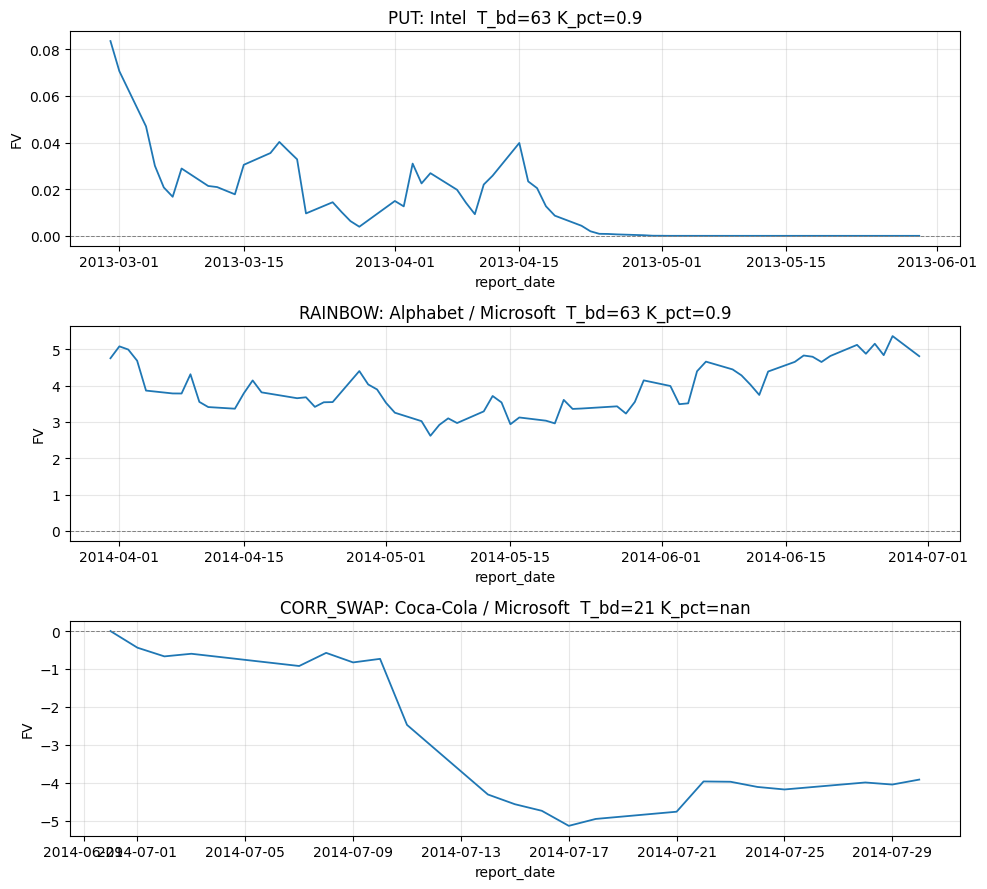

In [25]:
def plot_one_contract(fv_df, inc_df, product_type, ax, title_suffix=''):
    pool = inc_df.loc[inc_df['product_type'] == product_type]
    sample = pool.iloc[len(pool) // 2]
    mask = (
        (fv_df['product_type'] == product_type)
        & (fv_df['inception_date'] == pd.Timestamp(sample['inception_date']))
        & (fv_df['asset1'] == sample['asset1'])
        & (fv_df['maturity_bd'] == sample['maturity_bd'])
    )
    if product_type != 'CORR_SWAP':
        mask &= np.isclose(fv_df['strike_pct'].fillna(-1.0), float(sample['strike_pct']))
    if product_type != 'PUT':
        mask &= fv_df['asset2'] == sample['asset2']
    sub = fv_df.loc[mask].sort_values('report_date')
    if not len(sub):
        ax.set_title(f'{product_type}: no rows {title_suffix}')
        return
    ax.plot(sub['report_date'], sub['fv'], lw=1.3)
    ax.set_title(
        f"{product_type}: {sample['asset1']}"
        + (f" / {sample['asset2']}" if sample['asset2'] else '')
        + f"  T_bd={sample['maturity_bd']} K_pct={sample.get('strike_pct')}"
        + title_suffix
    )
    ax.set_xlabel('report_date')
    ax.set_ylabel('FV')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.7, ls='--')

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
for ax, pt in zip(axes, ['PUT', 'RAINBOW', 'CORR_SWAP']):
    plot_one_contract(all_fv, inc_df, pt, ax)
fig.tight_layout()

## 5. CORR_SWAP P&L decomposition over life

Plot `elapsed_pl`, `future_pl_est` and total `fv` for one swap. They sum (after discounting) to `fv`.
At inception: both ~ 0. At maturity: `elapsed_pl == fv`, `future_pl_est == 0`.

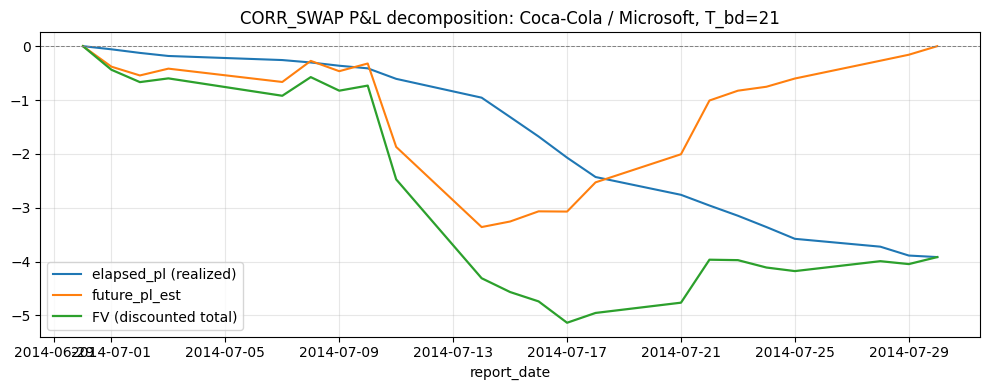

In [26]:
sw_pool = inc_df.loc[inc_df['product_type'] == 'CORR_SWAP']
sample = sw_pool.iloc[len(sw_pool) // 2]
mask = (
    (all_fv['product_type'] == 'CORR_SWAP')
    & (all_fv['inception_date'] == pd.Timestamp(sample['inception_date']))
    & (all_fv['asset1'] == sample['asset1'])
    & (all_fv['asset2'] == sample['asset2'])
    & (all_fv['maturity_bd'] == sample['maturity_bd'])
)
sub = all_fv.loc[mask].sort_values('report_date')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sub['report_date'], sub['elapsed_pl'], label='elapsed_pl (realized)')
ax.plot(sub['report_date'], sub['future_pl_est'], label='future_pl_est')
ax.plot(sub['report_date'], sub['fv'], label='FV (discounted total)', lw=1.6)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_title(f"CORR_SWAP P&L decomposition: {sample['asset1']} / {sample['asset2']}, T_bd={sample['maturity_bd']}")
ax.set_xlabel('report_date')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 6. Smile / term structure: inception prices vs strike and maturity

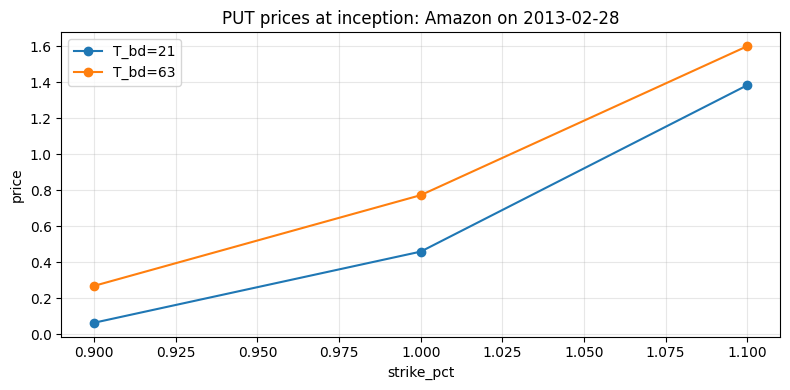

In [27]:
puts = inc_df.loc[inc_df['product_type'] == 'PUT']
any_asset = puts['asset1'].iloc[0]
any_date = puts['inception_date'].iloc[len(puts) // 2]
sub_puts = puts.loc[(puts['asset1'] == any_asset) & (puts['inception_date'] == any_date)]

fig, ax = plt.subplots(figsize=(8, 4))
for T_bd, g in sub_puts.groupby('maturity_bd'):
    ax.plot(g['strike_pct'], g['price_inception'], marker='o', label=f'T_bd={T_bd}')
ax.set_title(f'PUT prices at inception: {any_asset} on {pd.Timestamp(any_date).date()}')
ax.set_xlabel('strike_pct')
ax.set_ylabel('price')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 7. Hedge decomposition demo  <!-- rainbow_hedge_decomposition_demo_section_v1 -->

Greeks-match decomposition of `max(S1, S2, K) = K + C_max` into a linear
combination of two underlyings, two vanilla calls (struck at K with maturity
T), one single-payment correlation swap and a zero-coupon bond.

See `rainbow_hedge_decomposition.py`.


In [58]:
from typing import Literal


import importlib
import rainbow_corr_dataset
import rainbow_hedge_decomposition
importlib.reload(rainbow_corr_dataset)
importlib.reload(rainbow_hedge_decomposition)
from rainbow_corr_dataset import precompute_market_state
from rainbow_hedge_decomposition import (
    simulate_hedge_trajectory,
    plot_static_hedge_grid,
    plot_dynamic_hedge_grid,
    build_hedge_dataset,
    hedge_residual,
)

hedge_pair = ('Apple', 'Microsoft')
hedge_assets = list[Literal[
    'Apple', 
    'Microsoft'
]](hedge_pair)
state = precompute_market_state(price_data, derivative_filter=hedge_assets, verbose=False)
print('state keys:', list[str](state.keys()))
print('pairs:', state['pairs'])
print('calendar:', state['calendar'][0].date(), '->', state['calendar'][-1].date())

state keys: ['close', 'log_returns', 'sigma_ann', 'rho_21d', 'ar1_params', 'pairs', 'assets', 'calendar', 'delta_t']
pairs: [('Apple', 'Microsoft')]
calendar: 1998-01-02 -> 2024-12-31


### 7.1 Single trajectory (Apple × Microsoft, T=63bd, K_pct=1.0)

Dynamic mode: hedge weights are updated every business day *after* recording
the current P&L point. ``hedge_residual`` checks
``pl_option ≈ pl_hedge - (cum_cost - cum_cost(t0))``.


In [51]:
traj_d = simulate_hedge_trajectory(
    state, 'Apple', 'Microsoft',
    inception_date='2022-01-31',
    maturity_bd=63, strike_pct=1.0,
    mode='dynamic',
)
print('rows:', len(traj_d))
print('initial mv_hedge / (K + C_max):', traj_d['mv_hedge'].iloc[0], '/',
      traj_d['strike_abs'].iloc[0] + traj_d['C_max'].iloc[0])
print('terminal pl_option / pl_hedge / (cum_cost - cum_cost(0)):',
      traj_d['pl_option'].iloc[-1],
      traj_d['pl_hedge'].iloc[-1],
      traj_d['cum_cost'].iloc[-1] - traj_d['cum_cost'].iloc[0])
res = hedge_residual(traj_d)
print(f'dynamic residual: max abs = {res.abs().max():.4f}, std = {res.std():.4f}')
traj_d[['report_date', 'C_max', 'pl_option', 'pl_hedge', 'cum_cost']].head()


rows: 64
initial mv_hedge / (K + C_max): 331.0026069769047 / 331.00260697690476
terminal pl_option / pl_hedge / (cum_cost - cum_cost(0)): -20.022595990576633 -19.985572357049875 -2.295460330860749
dynamic residual: max abs = 2.3325, std = 0.6893


,report_date,C_max,pl_option,pl_hedge,cum_cost
0,2022-01-31,20.022596,0.000000,0.000000,331.002607
1,2022-02-01,18.638971,-1.383625,-1.346602,331.002607
2,2022-02-02,21.488725,1.466129,1.503147,330.965583
3,2022-02-03,16.260278,-3.762318,-3.725294,330.928565
4,2022-02-04,17.259649,-2.762947,-2.725923,330.891542


### 7.2 Static hedge grid (4×3 inception dates)

12 subplots (BME inceptions of 2022). Per (K_pct, T_bd): ``pl_option`` (solid)
vs static ``pl_hedge`` (dashed).


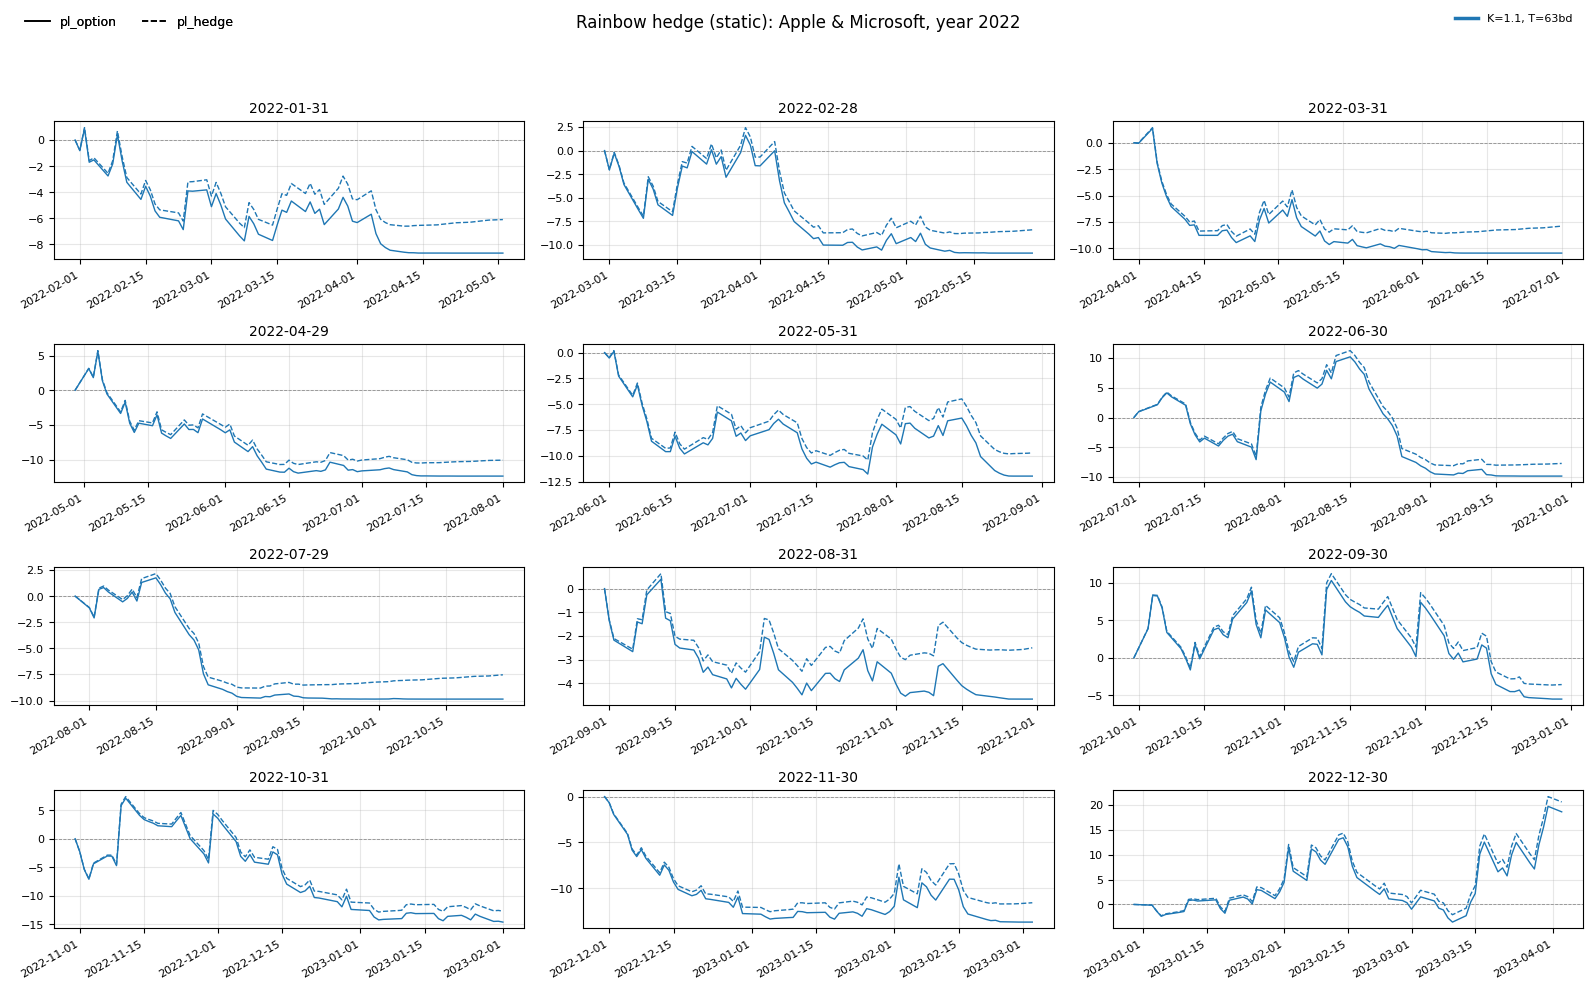

In [52]:
fig, _ = plot_static_hedge_grid(
    state, 'Apple', 'Microsoft', 
    year=2022,
    strikes=(1.1,), #(0.9, 1.0, 1.1),
    maturities=(63,),
)


### 7.3 Dynamic hedge grid
Three lines per (K_pct, T_bd): ``pl_option`` (solid), ``pl_hedge`` (dashed),
``cum_cost - cum_cost(t0)`` (dotted).


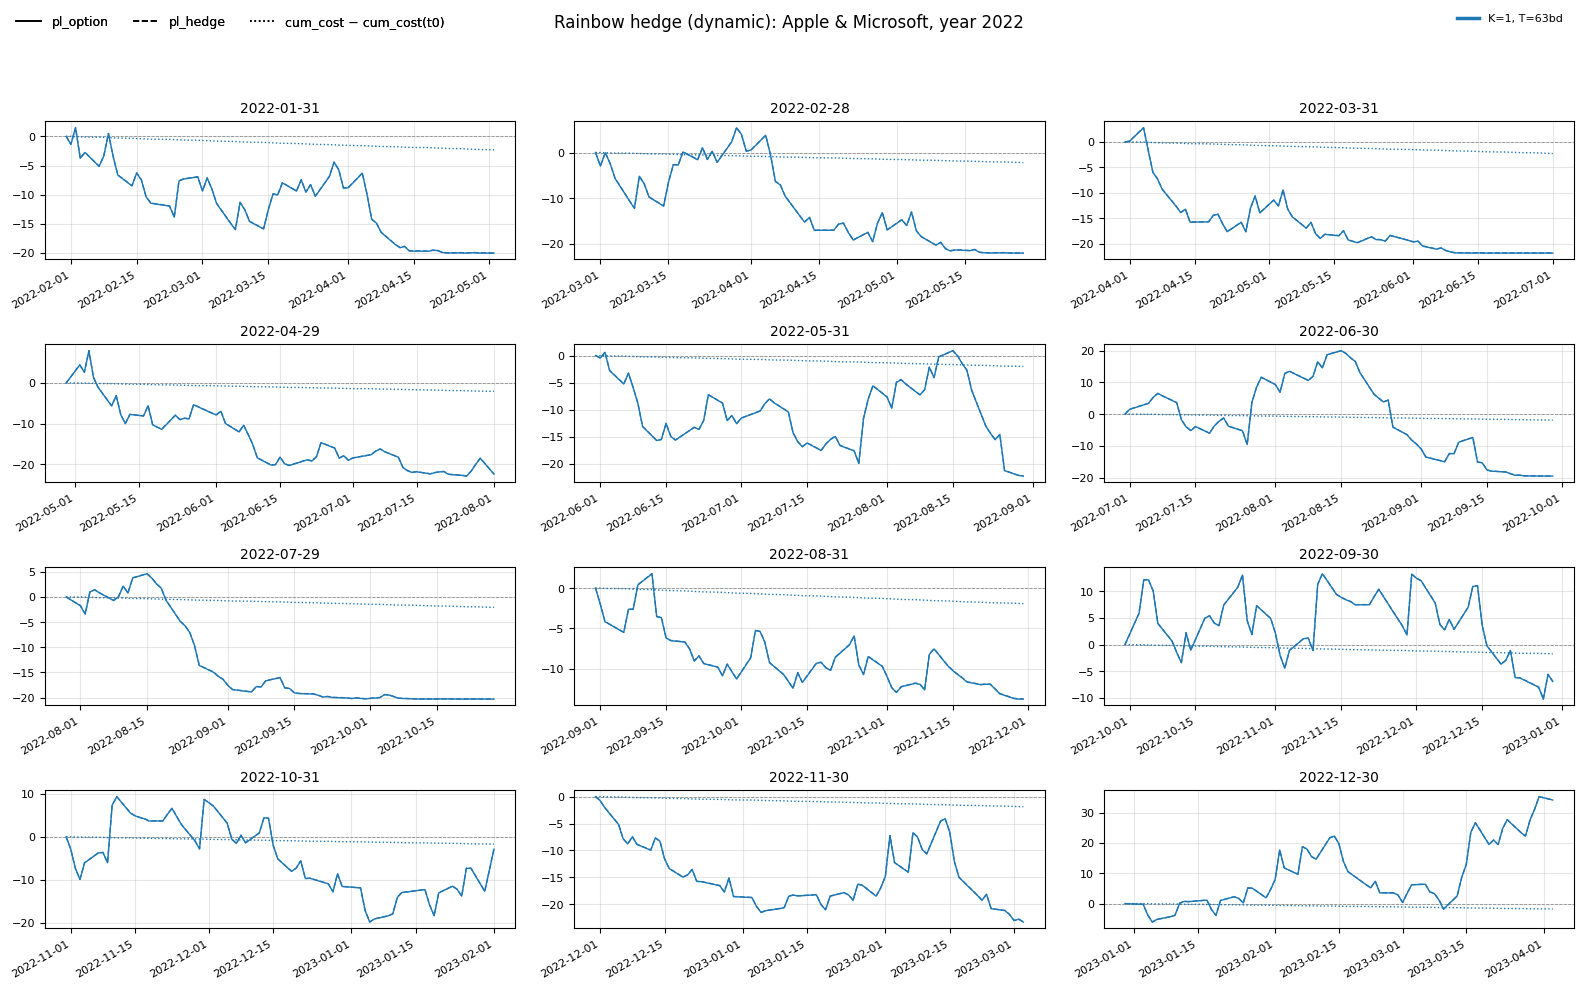

In [ ]:
fig2, _ = plot_dynamic_hedge_grid(
    state, 'Apple', 'Microsoft', year=2022,
    strikes=(1.0,), maturities=(63,),
)


### 7.4 Build hedge-trajectory parquet
Writes ``hedge_trajectory.parquet`` under ``ml output/rainbow_hedge_demo``.


In [ ]:
# import os, shutil
# hedge_out_dir = os.path.join('ml output', 'rainbow_hedge_demo')
# if os.path.isdir(hedge_out_dir):
#     shutil.rmtree(hedge_out_dir)

# info = build_hedge_dataset(
#     state,
#     output_dir=hedge_out_dir,
#     asset_pairs=[('Apple', 'Microsoft')],
#     maturities_bd=(21, 63),
#     strike_pcts=(0.9, 1.0, 1.1),
#     modes=('static', 'dynamic'),
#     inception_freq='BME',
#     warmup_bd=252,
#     cooldown_bd=63,
#     verbose=True,
# )
# info


  pair 1/1 ('Apple', 'Microsoft'): 3708 contracts total
Wrote ml output\rainbow_hedge_demo\hedge_trajectory.parquet -- 159444 rows, 3708 contracts


{'output_path': 'ml output\\rainbow_hedge_demo\\hedge_trajectory.parquet',
 'n_rows': 159444,
 'n_contracts': 3708}

## Далее тестирую гипотезы

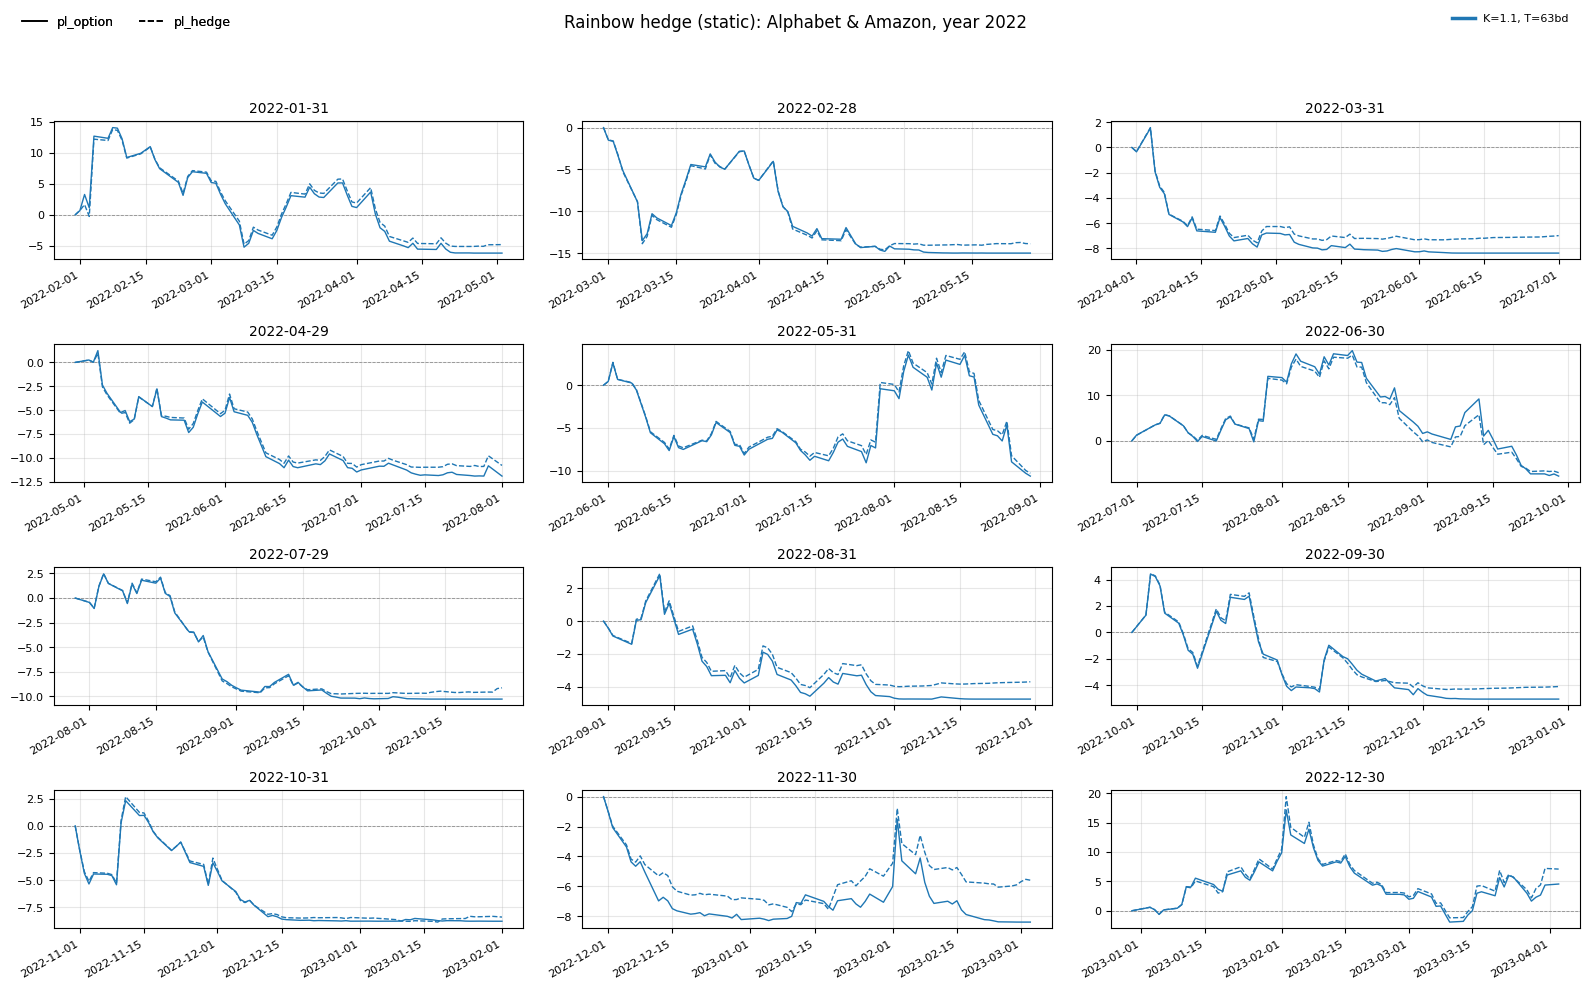

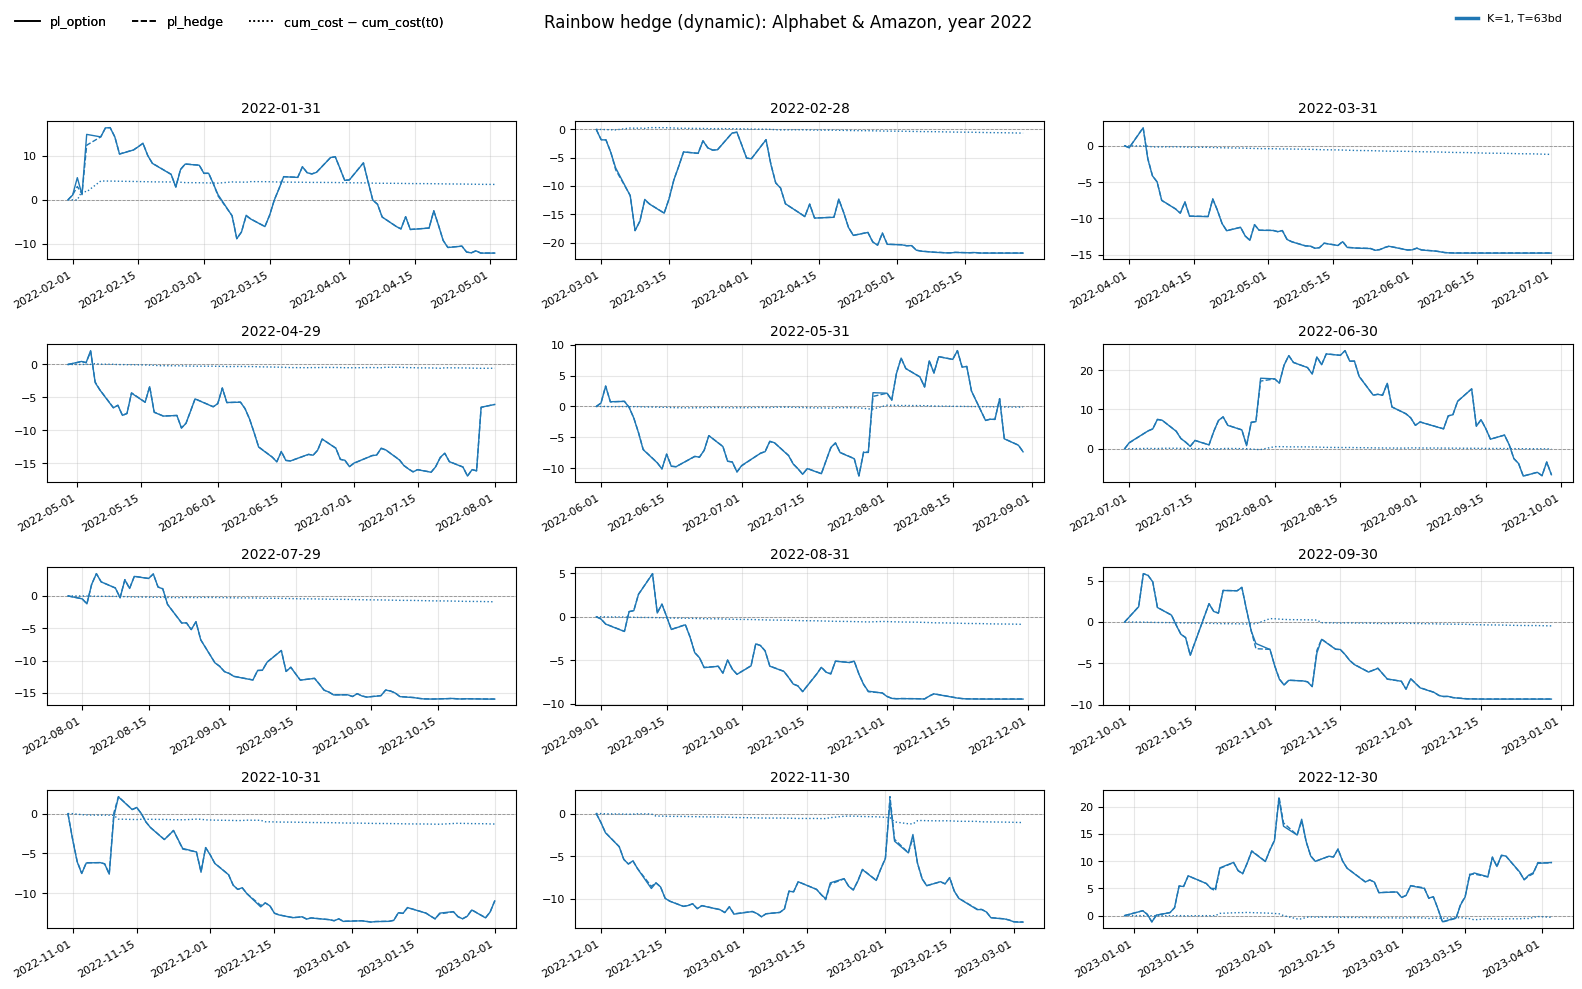

In [55]:
asset1_name = 'Alphabet'
asset2_name = 'Amazon'
year = 2022
inception_date = '2022-01-31'

# "Apple"      
# "Microsoft"  
# "Alphabet"   
# "Amazon"     
# "Meta"       
# "Nvidia"     
# "Tesla"      
# "Cisco"      
# "Intel"      
# "Oracle"     
# "Chevron"    
# "Visa"       
# "Walmart"    
# "Exxon Mobil"
# "Coca-Cola"  
# "PepsiCo"    

hedge_pair = (asset1_name, asset2_name)
hedge_assets = list[Literal[
    asset1_name, 
    asset2_name
]](hedge_pair)
state = precompute_market_state(price_data, derivative_filter=hedge_assets, verbose=False)

traj_d = simulate_hedge_trajectory(
    state, asset1_name, asset2_name,
    inception_date=inception_date,
    maturity_bd=63, strike_pct=1.0,
    mode='dynamic',
)

res = hedge_residual(traj_d)

fig, _ = plot_static_hedge_grid(
    state, asset1_name, asset2_name, 
    year=year,
    strikes=(1.1,), #(0.9, 1.0, 1.1),
    maturities=(63,),
)

fig2, _ = plot_dynamic_hedge_grid(
    state, asset1_name, asset2_name, year=year,
    strikes=(1.0,), maturities=(63,),
)



## 8. Hedge error dataset and residual CatBoost

Dataset: cross-sectional hedge tracking error `err = pl_option - pl_hedge` for `delta_static`, `delta_dynamic`, `greek_static`, `greek_dynamic`. Train CatBoost to predict **contemporaneous** `err` on `delta_dynamic` rows with `report_date < 2020-01-01`, using **only underlyings, vols, correlation and contract terms** as features (**no** option fair value / `C_max` / `pl_option` / `pl_hedge` as inputs).

**CatBoost inputs already include contract shape:** `strike_pct`, `maturity_bd`, `strike_abs`, plus `tau_rem`, `elapsed_bd`, `remaining_bd`, and spots/vols/corr (`S1`, `S2`, `sigma1`, `sigma2`, `rho`). See `RESIDUAL_FEATURE_COLUMNS` in `rainbow_hedge_errors.py`.

Test uses the cold-start date from full `state['calendar']` (first session after 2020-12-31, plus `max(maturities_bd)` business days). See `rainbow_hedge_errors.train_residual_mlp` (CatBoost backend). The next code cell builds errors for **several asset pairs** at once (`asset_pairs`); for a single pair, set `_MAX_ASSETS = 2` so only `(tickers[0], tickers[1])` is used.


In [74]:
from pathlib import Path
import itertools

from rainbow_corr_dataset import precompute_market_state, _build_inception_calendar
import importlib
import rainbow_hedge_errors as EH

importlib.reload(EH)

# Resolve code root: cwd may be .../code or repo parent (same dir as rainbow_corr_dataset.py)
_CODE = Path.cwd().resolve()
if not (_CODE / "rainbow_corr_dataset.py").is_file():
    _alt = _CODE / "code"
    if (_alt / "rainbow_corr_dataset.py").is_file():
        _CODE = _alt

# All unordered pairs from the first K names in `tickers`. K=2 -> only (tickers[0], tickers[1]).
_MAX_ASSETS = min(4, len(tickers))
_pair_names = list(tickers[:_MAX_ASSETS])
eh_pairs = list(itertools.combinations(_pair_names, 2))
print(f"Hedge-error pairs ({len(eh_pairs)}):", eh_pairs)

all_deriv_names = sorted({name for p in eh_pairs for name in p})
eh_state = precompute_market_state(
    price_data,
    derivative_filter=all_deriv_names,
    verbose=False,
)
eh_pair = eh_pairs[0]

hedge_err_dir = str(_CODE / "ml output" / "hedge_errors_demo")
if os.path.isdir(hedge_err_dir):
    shutil.rmtree(hedge_err_dir)

maturities_demo = (21, 63)
build_info = EH.build_hedge_error_dataset(
    eh_state,
    output_dir=hedge_err_dir,
    asset_pairs=eh_pairs,
    maturities_bd=maturities_demo,
    strike_pcts=(0.9, 1.0, 1.1),
    inception_freq='BME',
    warmup_bd=252,
    cooldown_bd=63,
    verbose=True,
)
df_err = pd.read_parquet(build_info['long_path'])
print('Rows per (asset1, asset2):')
print(df_err.groupby(['asset1', 'asset2'], sort=False).size())
build_info


Hedge-error pairs (6): [('Apple', 'Microsoft'), ('Apple', 'Alphabet'), ('Apple', 'Amazon'), ('Microsoft', 'Alphabet'), ('Microsoft', 'Amazon'), ('Alphabet', 'Amazon')]


  pair 1/6 ('Apple', 'Microsoft'): 7416 contract-strategy runs
  pair 2/6 ('Apple', 'Alphabet'): 13200 contract-strategy runs
  pair 3/6 ('Apple', 'Amazon'): 20616 contract-strategy runs
  pair 4/6 ('Microsoft', 'Alphabet'): 26400 contract-strategy runs
  pair 5/6 ('Microsoft', 'Amazon'): 33816 contract-strategy runs
  pair 6/6 ('Alphabet', 'Amazon'): 39600 contract-strategy runs
Wrote C:\Users\Vladimir\Documents\МФТИ\Диплом\code\ml output\hedge_errors_demo\hedge_errors.parquet (1702800 rows)
Wrote C:\Users\Vladimir\Documents\МФТИ\Диплом\code\ml output\hedge_errors_demo\hedge_errors_aggregated.parquet (26088 rows)
Rows per (asset1, asset2):
asset1     asset2   
Apple      Microsoft    318888
           Alphabet     248712
           Amazon       318888
Microsoft  Alphabet     248712
           Amazon       318888
Alphabet   Amazon       248712
dtype: int64


{'long_path': 'C:\\Users\\Vladimir\\Documents\\МФТИ\\Диплом\\code\\ml output\\hedge_errors_demo\\hedge_errors.parquet',
 'agg_path': 'C:\\Users\\Vladimir\\Documents\\МФТИ\\Диплом\\code\\ml output\\hedge_errors_demo\\hedge_errors_aggregated.parquet',
 'n_rows': 1702800,
 'n_contract_runs': 39600}

In [75]:
# Ускоренный старт: только прочитать parquet (без build_hedge_error_dataset).
# Нужны pandas и pyarrow. maturities_demo задайте так же, как при сборке (для ячеек ниже).
from pathlib import Path

_CODE = Path.cwd().resolve()
if not (_CODE / "rainbow_corr_dataset.py").is_file():
    _alt = _CODE / "code"
    if (_alt / "rainbow_corr_dataset.py").is_file():
        _CODE = _alt

hedge_err_dir = str(_CODE / "ml output" / "hedge_errors_demo")
_parquet = os.path.join(hedge_err_dir, "hedge_errors.parquet")
if not os.path.isfile(_parquet):
    raise FileNotFoundError(
        f"Нет файла:\n  {_parquet}\n"
        "Сначала выполните ячейку сборки датасета или проверьте cwd ядра (рядом должен быть rainbow_corr_dataset.py)."
    )
df_err = pd.read_parquet(_parquet)
maturities_demo = (21, 63)
len(df_err)

1702800

In [76]:
df_err = pd.read_parquet(os.path.join(hedge_err_dir, "hedge_errors.parquet"))

In [77]:
nn_dir = os.path.join(hedge_err_dir, 'residual_nn')
if os.path.isdir(nn_dir):
    shutil.rmtree(nn_dir)

nn_out = EH.train_residual_mlp(
    df_err,
    train_report_before='2020-01-01',
    max_maturity_bd=max(maturities_demo),
    calendar=eh_state['calendar'],
    output_dir=nn_dir,
    iterations=3000,
    depth=8,
    learning_rate=0.04,
    early_stopping_rounds=100,
    x_scaler_type='robust',
    scale_target=True,
    verbose=True,
)
nn_out['metrics']


t_test_start: 2021-04-06
train rows: 334800 test rows: 67482
metrics: {'rmse_delta_dynamic_test': 0.542180578086063, 'mae_delta_dynamic_test': 0.2360017076789955, 'rmse_nn_adjusted_test': 0.5422521298832323, 'mae_nn_adjusted_test': 0.23765338197879343, 'n_test': 67482.0}


{'rmse_delta_dynamic_test': 0.542180578086063,
 'mae_delta_dynamic_test': 0.2360017076789955,
 'rmse_nn_adjusted_test': 0.5422521298832323,
 'mae_nn_adjusted_test': 0.23765338197879343,
 'n_test': 67482.0}

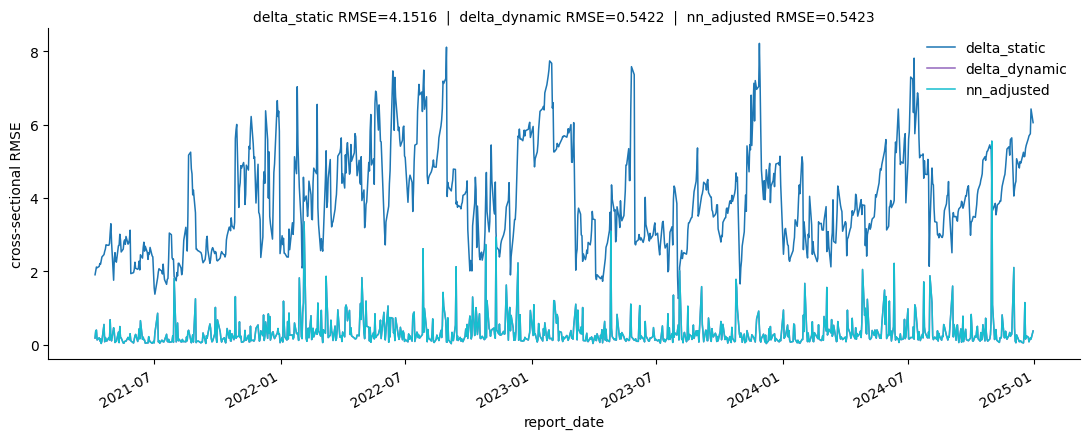

In [78]:
fig_cmp, _ = EH.plot_hedge_error_comparison_pooled_rmse_title(
    df_err,
    report_date_start=nn_out['t_test_start'],
    nn_pred_df=nn_out.get('pred_df'),
)
plt.show()


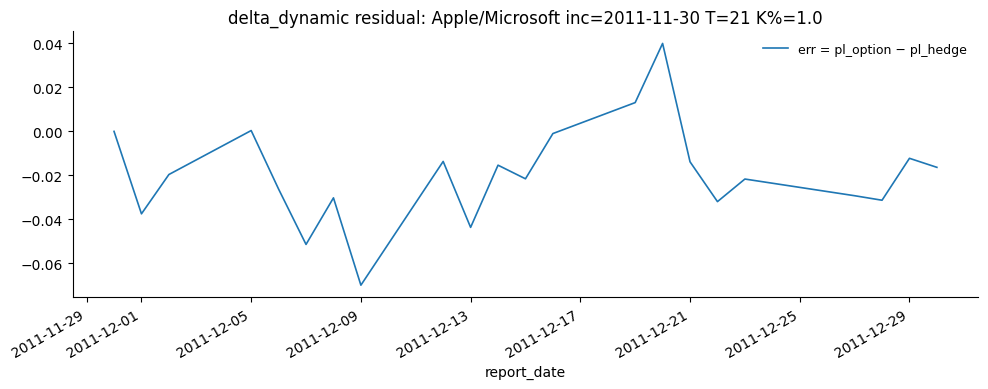

In [79]:
inc_demo = _build_inception_calendar(
    eh_state['calendar'],
    inception_freq='BME',
    warmup_bd=252,
    cooldown_bd=63,
)
inception_mid = pd.Timestamp(inc_demo[len(inc_demo) // 2])
fig_r, _ = EH.plot_residual_dynamics(
    eh_state,
    eh_pair[0],
    eh_pair[1],
    inception_date=inception_mid,
    maturity_bd=maturities_demo[0],
    strike_pct=1.0,
    strategy=EH.STRATEGY_DELTA_DYNAMIC,
)
plt.show()


## 9. Direct rainbow (Stulz) price: proposed MLP

**Goal:** map **inception** observables to the Stulz max-call price `C_max` (same object as in hedge trajectories), **without** passing `C_max` as an input.

**Inputs (code below):** `S1`, `S2` at inception; strike `K` (`strike_abs`); `tau = maturity_bd * delta_t`; Black–Scholes vanilla calls `C1`, `C2` with the same `K` and `tau`; plus `sigma1`, `sigma2`, `rho`, `strike_pct` for stability.

**Target:** `C_max` (Stulz fair value at inception). Short demo training only — expand epochs, data, and architecture for thesis experiments.


In [73]:
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from rainbow_hedge_decomposition import bs_call_price

_R = 0.03
_Q = 0.0
_dt = float(eh_state.get("delta_t", 1.0 / 252.0))

inc_rows = df_err.loc[(df_err["strategy"] == EH.STRATEGY_DELTA_DYNAMIC) & (df_err["elapsed_bd"] == 0)].copy()
inc_rows = inc_rows.drop_duplicates(subset=["inception_date", "asset1", "asset2", "maturity_bd", "strike_pct"])
if len(inc_rows) < 20:
    print("Need df_err from sec.8 with enough rows; got", len(inc_rows))
else:
    S1 = inc_rows["S1"].to_numpy(dtype=float)
    S2 = inc_rows["S2"].to_numpy(dtype=float)
    K = inc_rows["strike_abs"].to_numpy(dtype=float)
    tau = inc_rows["maturity_bd"].to_numpy(dtype=float) * _dt
    sig1 = inc_rows["sigma1"].to_numpy(dtype=float)
    sig2 = inc_rows["sigma2"].to_numpy(dtype=float)
    rho = inc_rows["rho"].to_numpy(dtype=float)
    pct = inc_rows["strike_pct"].to_numpy(dtype=float)
    C1 = bs_call_price(S1, K, sig1, tau, r=_R, q=_Q)
    C2 = bs_call_price(S2, K, sig2, tau, r=_R, q=_Q)
    y = inc_rows["C_max"].to_numpy(dtype=float)
    X = np.column_stack([S1, S2, K, tau, C1, C2, sig1, sig2, rho, pct])

    class RainbowPriceMLP(nn.Module):
        def __init__(self, n_in: int, hidden=(96, 64)):
            super().__init__()
            layers = []
            d = n_in
            for h in hidden:
                layers += [nn.Linear(d, h), nn.ReLU()]
                d = h
            layers.append(nn.Linear(d, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
    sx = StandardScaler().fit(X_tr)
    sy = StandardScaler().fit(y_tr.reshape(-1, 1))
    X_trs = sx.transform(X_tr)
    X_tes = sx.transform(X_te)
    y_trs = sy.transform(y_tr.reshape(-1, 1)).ravel()
    Xt = torch.from_numpy(X_trs).float()
    yt = torch.from_numpy(y_trs).float()
    mlp_price = RainbowPriceMLP(X.shape[1])
    opt = torch.optim.Adam(mlp_price.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    mlp_price.train()
    for _ in range(80):
        opt.zero_grad()
        pr = mlp_price(Xt)
        loss = loss_fn(pr, yt)
        loss.backward()
        opt.step()
    mlp_price.eval()
    with torch.no_grad():
        pred_te = mlp_price(torch.from_numpy(X_tes).float()).numpy()
    pred_te_un = sy.inverse_transform(pred_te.reshape(-1, 1)).ravel()
    rmse = float(np.sqrt(np.mean((pred_te_un - y_te) ** 2)))
    print("RainbowPriceMLP test RMSE (C_max):", rmse, " n_train", len(X_tr), "n_test", len(X_te))


RainbowPriceMLP test RMSE (C_max): 0.48048846202454587  n_train 1483 n_test 371


## 8.2. Дополнительный эксперимент: две пары активов

Раздел **§8 выше не меняется**. Отдельный каталог `ml output/hedge_errors_two_pairs_demo`, две фиксированные пары инструментов. Для каждой пары — график RMSE (pooled) и график MAE.


In [ ]:
from pathlib import Path
import importlib
import os
import shutil

import matplotlib.pyplot as plt
import rainbow_hedge_errors as EH
from rainbow_corr_dataset import precompute_market_state

importlib.reload(EH)

_CODE = Path.cwd().resolve()
if not (_CODE / "rainbow_corr_dataset.py").is_file():
    _alt = _CODE / "code"
    if (_alt / "rainbow_corr_dataset.py").is_file():
        _CODE = _alt

if len(tickers) >= 4:
    CMP_PAIR_A = (tickers[0], tickers[1])
    CMP_PAIR_B = (tickers[2], tickers[3])
elif len(tickers) >= 2:
    CMP_PAIR_A = (tickers[0], tickers[1])
    CMP_PAIR_B = (tickers[0], tickers[-1])
else:
    raise ValueError("Нужно минимум 2 тикера в tickers")

cmp_pairs_list = [CMP_PAIR_A, CMP_PAIR_B]
print("Пары для §8.2:", cmp_pairs_list)

cmp_deriv_names = sorted({x for p in cmp_pairs_list for x in p})
eh_state_cmp = precompute_market_state(
    price_data, derivative_filter=cmp_deriv_names, verbose=False
)

hedge_err_dir_cmp = str(_CODE / "ml output" / "hedge_errors_two_pairs_demo")
if os.path.isdir(hedge_err_dir_cmp):
    shutil.rmtree(hedge_err_dir_cmp)

maturities_cmp = (21, 63)
build_cmp = EH.build_hedge_error_dataset(
    eh_state_cmp,
    output_dir=hedge_err_dir_cmp,
    asset_pairs=cmp_pairs_list,
    maturities_bd=maturities_cmp,
    strike_pcts=(0.9, 1.0, 1.1),
    inception_freq="BME",
    warmup_bd=252,
    cooldown_bd=63,
    verbose=True,
)
df_err_cmp = pd.read_parquet(build_cmp["long_path"])
print(df_err_cmp.groupby(["asset1", "asset2"], sort=False).size())

nn_dir_cmp = os.path.join(hedge_err_dir_cmp, "residual_nn")
if os.path.isdir(nn_dir_cmp):
    shutil.rmtree(nn_dir_cmp)
nn_cmp = EH.train_residual_mlp(
    df_err_cmp,
    train_report_before="2020-01-01",
    max_maturity_bd=max(maturities_cmp),
    calendar=eh_state_cmp["calendar"],
    output_dir=nn_dir_cmp,
    iterations=2000,
    depth=8,
    learning_rate=0.04,
    early_stopping_rounds=80,
    verbose=False,
)
print(nn_cmp["metrics"])

for a, b in cmp_pairs_list:
    dfl = df_err_cmp.loc[(df_err_cmp["asset1"] == a) & (df_err_cmp["asset2"] == b)]
    pred_f = None
    pred_all = nn_cmp.get("pred_df")
    if pred_all is not None and len(pred_all):
        pred_f = pred_all.loc[
            (pred_all["asset1"] == a) & (pred_all["asset2"] == b)
        ]
    fig, ax = EH.plot_hedge_error_comparison_pooled_rmse_title(
        dfl,
        report_date_start=nn_cmp["t_test_start"],
        nn_pred_df=pred_f,
        subtitle=f"Пара {a} / {b}",
    )
    plt.show()

for a, b in cmp_pairs_list:
    dfl = df_err_cmp.loc[(df_err_cmp["asset1"] == a) & (df_err_cmp["asset2"] == b)]
    agg_mae = EH.aggregate_hedge_errors_by_date(dfl)
    fig, ax = EH.plot_hedge_error_comparison(
        agg_mae,
        report_date_start=nn_cmp["t_test_start"],
        metric="mae",
        strategies=(
            EH.STRATEGY_DELTA_STATIC,
            EH.STRATEGY_DELTA_DYNAMIC,
            EH.STRATEGY_GREEK_STATIC,
            EH.STRATEGY_GREEK_DYNAMIC,
        ),
    )
    ax.set_title(ax.get_title() + f" — пара {a} / {b}")
    plt.show()


## 9.1. Одна тестовая выборка: MLP для C_max и хедж с остатком

Те же активы `eh_pair` и строки `nn_out['pred_df']`. MLP учится на train по траектории, сравнение RMSE в `plot_compare_cmax_mlp_vs_residual_hedge`.


In [ ]:
import importlib
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import rainbow_hedge_errors as EH

importlib.reload(EH)

COMPARE_A, COMPARE_B = eh_pair
train_cut = pd.Timestamp("2020-01-01")
_R, _Q = 0.03, 0.0

pred_test = nn_out.get("pred_df")
if pred_test is None or len(pred_test) == 0:
    print("Нет nn_out['pred_df']: выполните ячейку обучения CatBoost в §8.")
else:
    pred_test = pred_test.loc[
        (pred_test["asset1"] == COMPARE_A) & (pred_test["asset2"] == COMPARE_B)
    ].copy()
    dd = df_err.loc[
        (df_err["strategy"] == EH.STRATEGY_DELTA_DYNAMIC)
        & (df_err["asset1"] == COMPARE_A)
        & (df_err["asset2"] == COMPARE_B)
    ].copy()
    train_dd = dd.loc[dd["report_date"] < train_cut]
    if len(train_dd) < 50 or len(pred_test) < 10:
        print("Мало строк для обучения/теста:", len(train_dd), len(pred_test))
    else:
        X_tr = EH.build_price_mlp_feature_matrix(train_dd, r=_R, q=_Q)
        y_tr = train_dd["C_max"].to_numpy(dtype=float)
        sx = StandardScaler().fit(X_tr)
        sy = StandardScaler().fit(y_tr.reshape(-1, 1))
        X_trs = sx.transform(X_tr)
        y_trs = sy.transform(y_tr.reshape(-1, 1)).ravel()
        X_te_raw = EH.build_price_mlp_feature_matrix(pred_test, r=_R, q=_Q)
        X_tes = sx.transform(X_te_raw)

        class RainbowPriceMLP(nn.Module):
            def __init__(self, n_in: int, hidden=(96, 64)):
                super().__init__()
                layers = []
                d = n_in
                for h in hidden:
                    layers += [nn.Linear(d, h), nn.ReLU()]
                    d = h
                layers.append(nn.Linear(d, 1))
                self.net = nn.Sequential(*layers)

            def forward(self, x):
                return self.net(x).squeeze(-1)

        mdl = RainbowPriceMLP(X_tr.shape[1])
        opt = torch.optim.Adam(mdl.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        Xt = torch.from_numpy(X_trs).float()
        yt = torch.from_numpy(y_trs).float()
        mdl.train()
        for _ in range(120):
            opt.zero_grad()
            pr = mdl(Xt)
            loss = loss_fn(pr, yt)
            loss.backward()
            opt.step()
        mdl.eval()
        with torch.no_grad():
            c_hat_s = mdl(torch.from_numpy(X_tes).float()).numpy()
        c_hat = sy.inverse_transform(c_hat_s.reshape(-1, 1)).ravel()

        fig, _axes = EH.plot_compare_cmax_mlp_vs_residual_hedge(
            pred_test.reset_index(drop=True),
            c_hat,
        )
        plt.show()
